# CNN — Acne Level Classification

In [1]:
# 1) Imports & konfigurasi dasar
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input

print('TensorFlow', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow 2.18.0
GPU available: False


In [2]:
# 2) CONFIG — sesuaikan jika perlu
CONFIG = {
    'train_csv': '../dataset/trainval_metadata.csv',
    'test_csv' : '../dataset/test_metadata.csv',
    'image_dir' : '../data/Agnedataset/JPEGImages',
    'img_size'  : (224, 224),
    'batch_size': 16,
    'epochs_head': 8,
    'epochs_finetune': 25,
    'head_lr'   : 1e-3,
    'finetune_lr': 1e-4,
    'num_classes': 4,
    'seed'      : 42,
    'model_output': '../output/best_model.keras',
    'class_names': ['Level 0','Level 1','Level 2','Level 3']
}
tf.random.set_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
os.makedirs(os.path.dirname(CONFIG['model_output']), exist_ok=True)


In [3]:
# 3) Load metadata and create proper file paths + stratified train/val split
def load_metadata(csv_path):
    df = pd.read_csv(csv_path)
    df = df[df['file_exists'] == True].copy()
    df = df[df['is_corrupt']  == False].copy()
    df = df.reset_index(drop=True)
    df['filepath'] = df['filepath'].astype(str)
    return df

df_all = load_metadata(CONFIG['train_csv'])
df_test = load_metadata(CONFIG['test_csv'])

# Stratified split: train / val (keep test untouched)
train_df, val_df = train_test_split(
    df_all, test_size=0.15, random_state=CONFIG['seed'],
    stratify=df_all['level']
)

print('Train:', len(train_df), ' Val:', len(val_df), ' Test:', len(df_test))
print(train_df['level'].value_counts().sort_index())

Train: 990  Val: 175  Test: 292
level
0    337
1    433
2    127
3     93
Name: count, dtype: int64


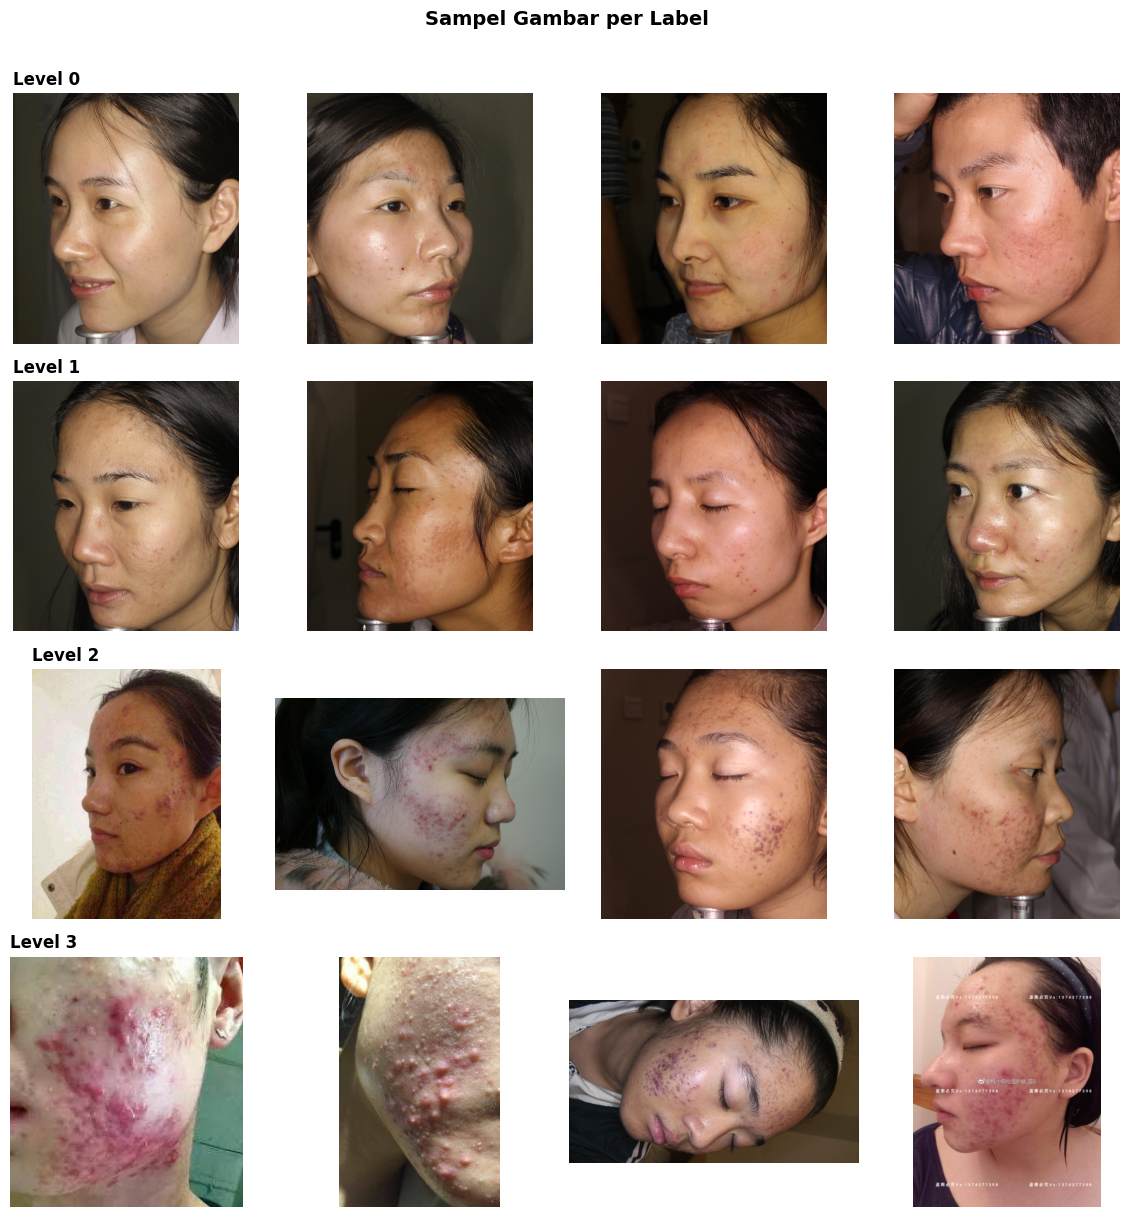

In [4]:
# 4) Tampilkan sampel gambar per label
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

CLASS_NAMES = {0: 'Level 0', 1: 'Level 1', 2: 'Level 2', 3: 'Level 3'}
n_samples = 4  # jumlah sampel per label

fig, axes = plt.subplots(
    nrows=len(CLASS_NAMES), ncols=n_samples,
    figsize=(n_samples * 3, len(CLASS_NAMES) * 3)
)

for row, (label, label_name) in enumerate(CLASS_NAMES.items()):
    samples = train_df[train_df['level'] == label].sample(
        n=n_samples, random_state=CONFIG['seed']
    )
    for col, (_, row_data) in enumerate(samples.iterrows()):
        img = mpimg.imread(row_data['filepath'])
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(label_name, fontsize=12, fontweight='bold', loc='left')

plt.suptitle('Sampel Gambar per Label', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [5]:
# 5) Class weights
labels = train_df['level'].values
classes = np.unique(labels)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=labels)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}
print('Class weight:', class_weight)

Class weight: {0: 0.7344213649851632, 1: 0.5715935334872979, 2: 1.9488188976377954, 3: 2.661290322580645}


In [6]:
# 6) Augmentation (Keras preprocessing layers)
IMG_H, IMG_W = CONFIG['img_size']
augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
    layers.RandomTranslation(0.06, 0.06),
    layers.RandomContrast(0.08),
])

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_H, IMG_W])
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)  # EfficientNet preprocessing (-1..1)
    return img, label

def build_dataset(df, augment=False, shuffle=True):
    paths = df['filepath'].values
    labels = df['level'].values.astype(np.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=CONFIG['seed'])
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(CONFIG['batch_size']).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = build_dataset(train_df, augment=True, shuffle=True)
val_ds   = build_dataset(val_df,   augment=False, shuffle=False)
test_ds  = build_dataset(df_test,  augment=False, shuffle=False)

for imgs, labels in train_ds.take(1):
    print('Train batch', imgs.shape, 'labels', labels.shape)

Train batch (16, 224, 224, 3) labels (16,)


In [7]:
# 7) Custom Loss Function — Focal Loss

@tf.keras.utils.register_keras_serializable()
class FocalLoss(keras.losses.Loss):
    def __init__(self, gamma=2.0, name='focal_loss'):
        super().__init__(name=name)
        self.gamma = gamma

    def call(self, y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_true_one_hot = tf.one_hot(y_true, depth=CONFIG['num_classes'])
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
        ce = -tf.reduce_sum(y_true_one_hot * tf.math.log(y_pred), axis=-1)
        pt = tf.reduce_sum(y_true_one_hot * y_pred, axis=-1)
        focal_weight = tf.pow(1.0 - pt, self.gamma)
        return tf.reduce_mean(focal_weight * ce)

    def get_config(self):
        config = super().get_config()
        config.update({'gamma': self.gamma})
        return config


focal_loss = FocalLoss(gamma=2.0)
print('FocalLoss siap digunakan.')


FocalLoss siap digunakan.


In [8]:
# 8) Build transfer learning model (EfficientNetB0)
def build_transfer_model(input_shape, num_classes, dropout=0.4):
    base = EfficientNetB0(include_top=False, weights='imagenet', input_shape=input_shape)
    base.trainable = False
    inputs = keras.Input(shape=input_shape)
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = keras.Model(inputs, outputs)
    return model, base

input_shape = CONFIG['img_size'] + (3,)
model, base = build_transfer_model(input_shape, CONFIG['num_classes'])
model.compile(optimizer=keras.optimizers.Adam(CONFIG['head_lr']),
              loss=focal_loss, metrics=['accuracy'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,559 (16.71 MB)

 Trainable params: 329,476 (1.26 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

In [9]:
# 9) Custom Callback — TrainingMonitor
import time

class TrainingMonitor(keras.callbacks.Callback):
    """Mencatat waktu per epoch dan menampilkan ringkasan di akhir training."""

    def __init__(self):
        super().__init__()
        self._epoch_times = []

    def on_epoch_begin(self, epoch, logs=None):
        self._t0 = time.time()

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self._t0
        self._epoch_times.append(elapsed)
        val_acc = logs.get('val_accuracy', 0)
        print(f" || Epoch {epoch+1} selesai dalam {elapsed:.1f}s — val_accuracy: {val_acc*100:.2f}%")

    def on_train_end(self, logs=None):
        avg = sum(self._epoch_times) / len(self._epoch_times)
        print(f"\n✅ Training selesai. Rata-rata waktu per epoch: {avg:.1f}s")


training_monitor = TrainingMonitor()
print('TrainingMonitor callback siap digunakan.')


TrainingMonitor callback siap digunakan.


In [10]:
# 10) Callbacks dan training head
callbacks = [
    training_monitor,
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint(CONFIG['model_output'], monitor='val_accuracy', save_best_only=True, verbose=1),
]
history_head = model.fit(
    train_ds,
    epochs=CONFIG['epochs_head'],
    validation_data=val_ds,
    class_weight=class_weight,
    callbacks=callbacks
)

print('Head training done')


Epoch 1/8
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.3468 - loss: 1.3796 || Epoch 1 selesai dalam 42.5s — val_accuracy: 54.86%

Epoch 1: val_accuracy improved from None to 0.54857, saving model to ../output/best_model.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 43s 505ms/step - accuracy: 0.3798 - loss: 1.2681 - val_accuracy: 0.5486 - val_loss: 0.4851 - learning_rate: 0.0010
Epoch 2/8
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.4717 - loss: 0.9666 || Epoch 2 selesai dalam 28.5s — val_accuracy: 47.43%

Epoch 2: val_accuracy did not improve from 0.54857
62/62 ━━━━━━━━━━━━━━━━━━━━ 29s 452ms/step - accuracy: 0.4596 - loss: 0.9412 - val_accuracy: 0.4743 - val_loss: 0.5159 - learning_rate: 0.0010
Epoch 3/8
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.4573 - loss: 0.7694 || Epoch 3 selesai dalam 28.4s — val_accuracy: 51.43%

Epoch 3: val_accuracy did not improve from 0.54857
62/62 ━━━━━━━━━━━━━━━━━━━━ 28s 452ms/step - accuracy: 0.4667 - loss: 0.7707 - val_accuracy: 0.5143

In [11]:
# 11) Fine-tune: unfreeze top layers of the base and continue training
# Unfreeze last ~40% of base layers
num_layers = len(base.layers)
fine_tune_at = int(num_layers * 0.6)
for layer in base.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base.layers[fine_tune_at:]:
    layer.trainable = True

model.compile(optimizer=keras.optimizers.Adam(CONFIG['finetune_lr']),
              loss=focal_loss, metrics=['accuracy'])

history_fine = model.fit(
    train_ds,
    epochs=CONFIG['epochs_head'] + CONFIG['epochs_finetune'],
    initial_epoch=history_head.epoch[-1] if hasattr(history_head, 'epoch') else 0,
    validation_data=val_ds,
    class_weight=class_weight,
    callbacks=callbacks
)
print('Fine-tuning done')

# Save final model
model.save(CONFIG['model_output'])
print('Saved model to', CONFIG['model_output'])

Epoch 8/33
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 598ms/step - accuracy: 0.4102 - loss: 0.8780 || Epoch 8 selesai dalam 69.4s — val_accuracy: 58.29%

Epoch 8: val_accuracy did not improve from 0.60571
62/62 ━━━━━━━━━━━━━━━━━━━━ 69s 710ms/step - accuracy: 0.4434 - loss: 0.7834 - val_accuracy: 0.5829 - val_loss: 0.4300 - learning_rate: 1.0000e-04
Epoch 9/33
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 593ms/step - accuracy: 0.4936 - loss: 0.6189 || Epoch 9 selesai dalam 41.4s — val_accuracy: 60.00%

Epoch 9: val_accuracy did not improve from 0.60571
62/62 ━━━━━━━━━━━━━━━━━━━━ 41s 660ms/step - accuracy: 0.5040 - loss: 0.5820 - val_accuracy: 0.6000 - val_loss: 0.4112 - learning_rate: 1.0000e-04
Epoch 10/33
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.5514 - loss: 0.4942 || Epoch 10 selesai dalam 40.7s — val_accuracy: 67.43%

Epoch 10: val_accuracy improved from 0.60571 to 0.67429, saving model to ../output/best_model.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 42s 666ms/step - accuracy: 0.5848 - loss: 0.4879 - val

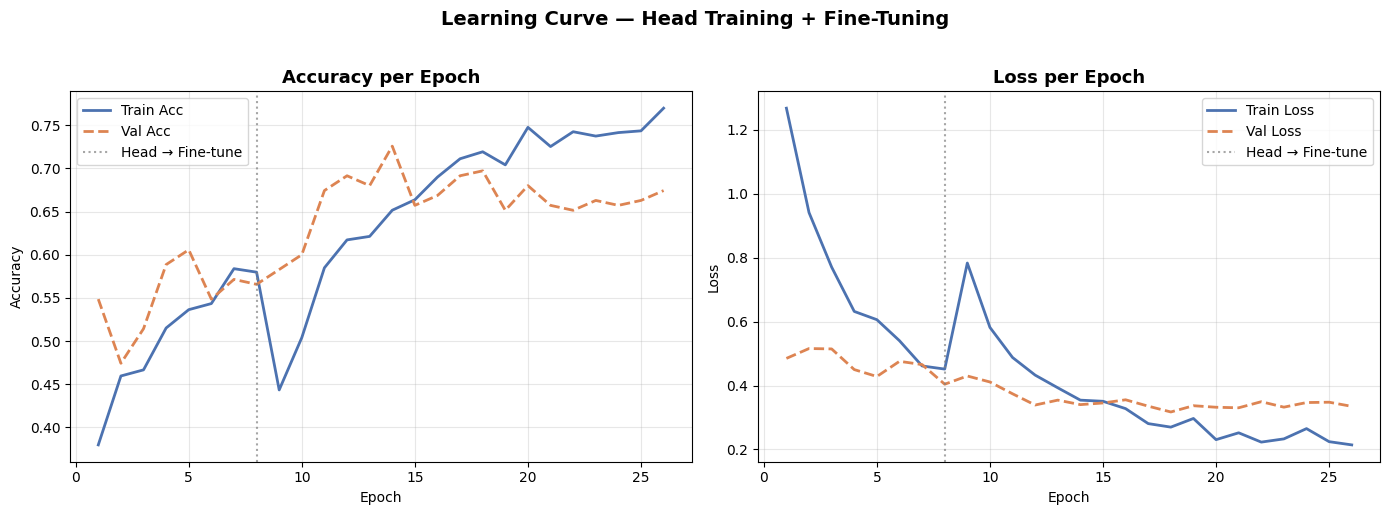

In [17]:
# 13) [PERBAIKAN] Visualisasi Learning Curve (train vs val)
#     Penting untuk mendeteksi overfitting atau underfitting.

def plot_learning_curve(hist_head, hist_fine):
    # Gabungkan history dua fase training
    acc     = hist_head.history['accuracy']     + hist_fine.history['accuracy']
    val_acc = hist_head.history['val_accuracy']  + hist_fine.history['val_accuracy']
    loss    = hist_head.history['loss']          + hist_fine.history['loss']
    val_loss= hist_head.history['val_loss']      + hist_fine.history['val_loss']
    epochs  = range(1, len(acc) + 1)

    # Garis pemisah antara fase head dan fine-tune
    head_end = len(hist_head.history['accuracy'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # — Accuracy —
    axes[0].plot(epochs, acc,     label='Train Acc',  color='#4C72B0', lw=2)
    axes[0].plot(epochs, val_acc, label='Val Acc',    color='#DD8452', lw=2, ls='--')
    axes[0].axvline(x=head_end, color='gray', ls=':', alpha=0.7,
                    label='Head → Fine-tune')
    axes[0].set_title('Accuracy per Epoch', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # — Loss —
    axes[1].plot(epochs, loss,     label='Train Loss', color='#4C72B0', lw=2)
    axes[1].plot(epochs, val_loss, label='Val Loss',   color='#DD8452', lw=2, ls='--')
    axes[1].axvline(x=head_end, color='gray', ls=':', alpha=0.7,
                    label='Head → Fine-tune')
    axes[1].set_title('Loss per Epoch', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.suptitle('Learning Curve — Head Training + Fine-Tuning',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_learning_curve(history_head, history_fine)


19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 369ms/step - accuracy: 0.6781 - loss: 0.3295
Test acc: 0.6780821681022644
              precision    recall  f1-score   support

     Level 0       0.70      0.78      0.74       100
     Level 1       0.66      0.73      0.69       128
     Level 2       0.64      0.19      0.29        37
     Level 3       0.69      0.74      0.71        27

    accuracy                           0.68       292
   macro avg       0.67      0.61      0.61       292
weighted avg       0.67      0.68      0.66       292



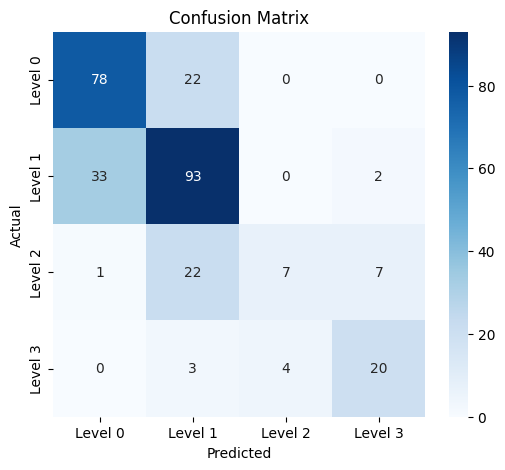

In [12]:
# 12) Evaluation on test set
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print('Test acc:', test_acc)

# Predictions & report
y_pred = np.argmax(model.predict(test_ds, verbose=0), axis=1)
y_true = np.concatenate([y.numpy() for _, y in test_ds])
print(classification_report(y_true, y_pred, target_names=CONFIG['class_names']))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CONFIG['class_names'], yticklabels=CONFIG['class_names'], cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

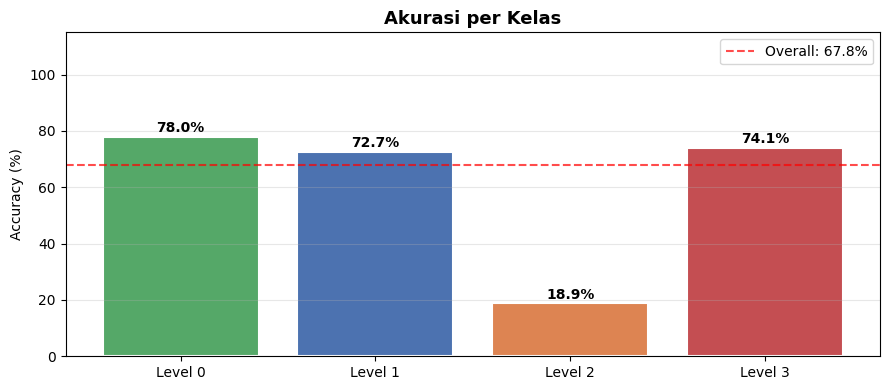

In [13]:
# 13) Akurasi per kelas + per-class F1
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(CONFIG['class_names'], per_class_acc * 100,
              color=['#55A868', '#4C72B0', '#DD8452', '#C44E52'], edgecolor='white', linewidth=1.5)
ax.axhline(y=test_acc*100, color='red', ls='--', alpha=0.7,
           label=f'Overall: {test_acc*100:.1f}%')
ax.set_title('Akurasi per Kelas', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim([0, 115])
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bar, v in zip(bars, per_class_acc):
    ax.text(bar.get_x()+bar.get_width()/2, v*100+1.5,
            f'{v*100:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

Model loaded dari: ../output/best_model.keras
Input shape  : (None, 224, 224, 3)
Output shape : (None, 4)


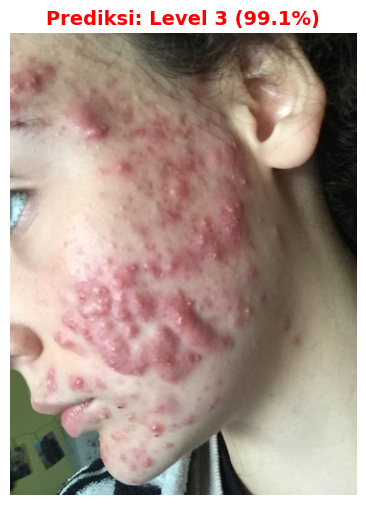


===== Hasil Prediksi =====
Gambar       : C:\Files\Picture\2461319055.jpg
Prediksi     : Level 3
Confidence   : 99.1%
Probabilitas per kelas:
  Level 0:                                  0.0%
  Level 1:                                  0.0%
  Level 2:                                  0.9%
  Level 3: █████████████████████████████   99.1%


In [14]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image           
from tensorflow.keras.applications.efficientnet import preprocess_input

# -- Konfigurasi --
MODEL_PATH   = '../output/best_model.keras'
CLASS_NAMES  = ['Level 0', 'Level 1', 'Level 2', 'Level 3']
IMG_SIZE     = (224, 224)

# -- Load model yang sudah dilatih --
inference_model = tf.keras.models.load_model(MODEL_PATH, compile=False)  # compile=False karena kita hanya butuh untuk inference
print(f'Model loaded dari: {MODEL_PATH}')
print(f'Input shape  : {inference_model.input_shape}')
print(f'Output shape : {inference_model.output_shape}')


def predict_and_show_image(image_path: str, model, img_size=IMG_SIZE, class_names=CLASS_NAMES):
    # 1. Baca & preprocessing gambar untuk model
    img_raw = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img_raw, channels=3)
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)
    img = tf.expand_dims(img, axis=0)

    # 2. Prediksi
    probs = model.predict(img, verbose=0)[0]   # shape (num_classes,)
    pred_idx = int(np.argmax(probs))
    
    predicted_class = class_names[pred_idx]
    confidence = float(probs[pred_idx])

    # 3. Tampilkan Gambar menggunakan Matplotlib
    plt.figure(figsize=(6, 6))
    
    # Membaca gambar asli menggunakan PIL agar warna saat di-plot normal
    raw_display_img = Image.open(image_path)
    plt.imshow(raw_display_img)
    
    # Memberikan judul plot berupa hasil prediksi & confidence
    plt.title(f"Prediksi: {predicted_class} ({confidence*100:.1f}%)", 
              fontsize=14, color='green' if pred_idx == 0 else 'red', fontweight='bold')
    plt.axis('off') # Menghilangkan sumbu x dan y agar lebih rapi
    plt.show()

    return {
        'predicted_class'    : predicted_class,
        'confidence'         : confidence,
        'all_probabilities'  : {cls: float(p) for cls, p in zip(class_names, probs)},
    }

TEST_IMAGE = r"C:\Files\Picture\2461319055.jpg"

# Memanggil fungsi yang baru
result = predict_and_show_image(TEST_IMAGE, inference_model)

print('\n===== Hasil Prediksi =====')
print(f"Gambar       : {TEST_IMAGE}")
print(f"Prediksi     : {result['predicted_class']}")
print(f"Confidence   : {result['confidence']*100:.1f}%")
print('Probabilitas per kelas:')
for cls, prob in result['all_probabilities'].items():
    bar = '█' * int(prob * 30)
    print(f"  {cls}: {bar:<30} {prob*100:5.1f}%")

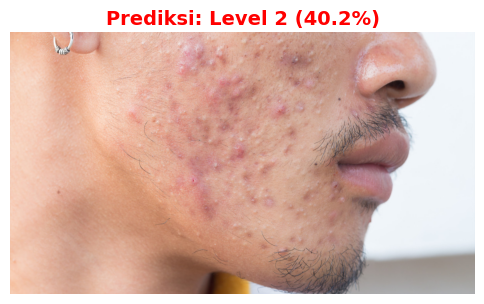


===== Hasil Prediksi =====
Gambar       : C:\Files\Picture\061709200_1564573098-6-Kiat-Mengatasi-Jerawat-Batu-pada-Wajah-By-Frank60-Shutterstock.jpg
Prediksi     : Level 2
Confidence   : 40.2%
Probabilitas per kelas:
  Level 0:                                  3.2%
  Level 1: ███████                         23.3%
  Level 2: ████████████                    40.2%
  Level 3: █████████                       33.3%


In [15]:
TEST_IMAGE2 = r"C:\Files\Picture\061709200_1564573098-6-Kiat-Mengatasi-Jerawat-Batu-pada-Wajah-By-Frank60-Shutterstock.jpg"

# Memanggil fungsi yang baru
result = predict_and_show_image(TEST_IMAGE2, inference_model)

print('\n===== Hasil Prediksi =====')
print(f"Gambar       : {TEST_IMAGE2}")
print(f"Prediksi     : {result['predicted_class']}")
print(f"Confidence   : {result['confidence']*100:.1f}%")
print('Probabilitas per kelas:')
for cls, prob in result['all_probabilities'].items():
    bar = '█' * int(prob * 30)
    print(f"  {cls}: {bar:<30} {prob*100:5.1f}%")

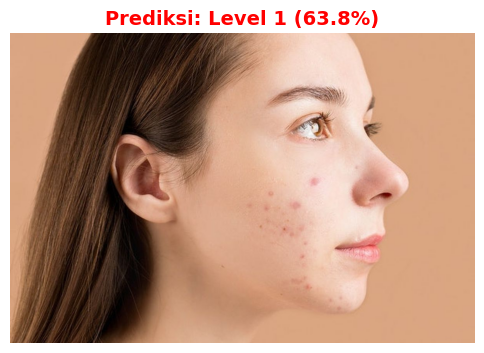


===== Hasil Prediksi =====
Gambar       : C:\Files\Picture\613f14b3d3035.jpg
Prediksi     : Level 1
Confidence   : 63.8%
Probabilitas per kelas:
  Level 0: ██████████                      33.8%
  Level 1: ███████████████████             63.8%
  Level 2:                                  2.3%
  Level 3:                                  0.1%


In [16]:
TEST_IMAGE3 = r"C:\Files\Picture\613f14b3d3035.jpg"

# Memanggil fungsi yang baru
result = predict_and_show_image(TEST_IMAGE3, inference_model)

print('\n===== Hasil Prediksi =====')
print(f"Gambar       : {TEST_IMAGE3}")
print(f"Prediksi     : {result['predicted_class']}")
print(f"Confidence   : {result['confidence']*100:.1f}%")
print('Probabilitas per kelas:')
for cls, prob in result['all_probabilities'].items():
    bar = '█' * int(prob * 30)
    print(f"  {cls}: {bar:<30} {prob*100:5.1f}%")


## Kesimpulan & Hasil Analisis Training Model

*Training* model menggunakan arsitektur **EfficientNetB0** dengan strategi *Two-Phase Training* (Fase 1: *Transfer Learning* 8 epoch, Fase 2: *Fine-Tuning* 25 epoch) sudah selesai dilakukan. Evaluasi dasar dan kendala utama selama eksperimen ini adalah sebagai berikut:

### 1. Masalah Utama: Kemiripan Visual Level 2 vs Level 3

Kendala paling menonjol dari hasil *training* ini adalah model masih sering tertukar dan bingung saat membedakan antara **Level 2 (Parah)** dan **Level 3 (Sangat Parah)**. Hal ini sangat wajar karena:

* **Fitur Visual Tumpang Tindih:** Secara fisik, perbedaan tingkat keparahan pada fase jerawat kronis ini sangat tipis. Kepadatan area kemerahan (eritema) dan sebaran nodul kista pada foto terlihat hampir mirip di mata model.

### 2. Analisis Akurasi & Ketidakseimbangan Data (*Imbalance Dataset*)

Performa akurasi model ini sangat dipengaruhi oleh distribusi data latih yang kita miliki:

* **Akurasi Bagus di Level Rendah:** Model pintar sekali mengenali Level 0 (337 sampel) dan Level 1 (433 sampel) karena datanya melimpah.
* **Akurasi Drop di Level Tinggi:** Akurasi di Level 2 (127 sampel) dan Level 3 (93 sampel) jeblok. Kurangnya jumlah sampel membuat model kurang belajar variasi bentuk jerawat parah, diperparah lagi dengan masalah kemiripan visual tadi.